In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
from sklearn import model_selection
from sklearn import metrics

In [21]:
voice_data = pd.read_csv('voice_gender.csv')
voice_data.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402905,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [24]:
voice_data.isnull().sum().sum()

np.int64(0)

In [29]:
X = voice_data.drop(columns=['label'])
y = voice_data['label']

In [30]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape: {}'.format(X_train.shape))
print('Test shape: {}'.format(X_test.shape))

Train shape: (2534, 20)
Test shape: (634, 20)


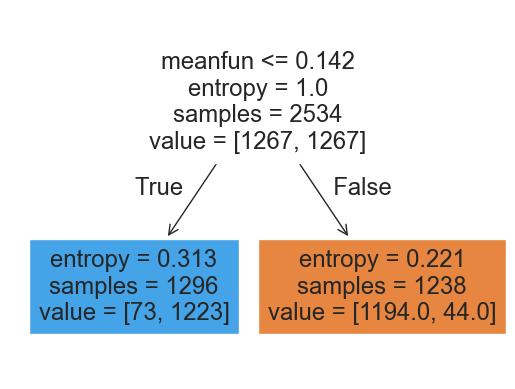

In [35]:
dt = tree.DecisionTreeClassifier(
    max_depth=1,
    criterion='entropy',
    random_state=42
)
dt.fit(X_train, y_train)

tree.plot_tree(
    decision_tree=dt,
    feature_names=X.columns,
    filled=True,
    impurity=True,
);

In [38]:
y_pred = dt.predict(X_test)
print("accuracy:", round(metrics.accuracy_score(y_test, y_pred), 3))

accuracy: 0.956


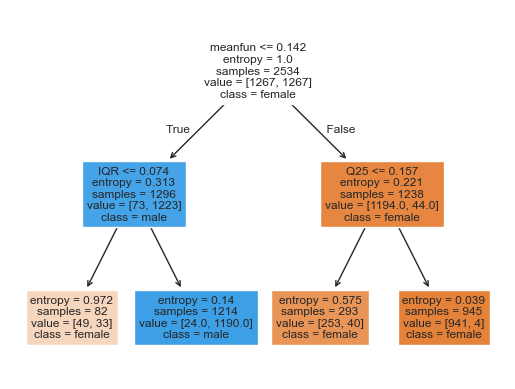

In [40]:
dt = tree.DecisionTreeClassifier(
    max_depth=2,
    criterion='entropy',
    random_state=42
)
dt.fit(X_train, y_train)

tree.plot_tree(
    decision_tree=dt,
    feature_names=X.columns,
    filled=True,
    impurity=True,
    class_names=dt.classes_
);

In [41]:
y_pred = dt.predict(X_test)
print("accuracy:", round(metrics.accuracy_score(y_test, y_pred), 3))

accuracy: 0.962


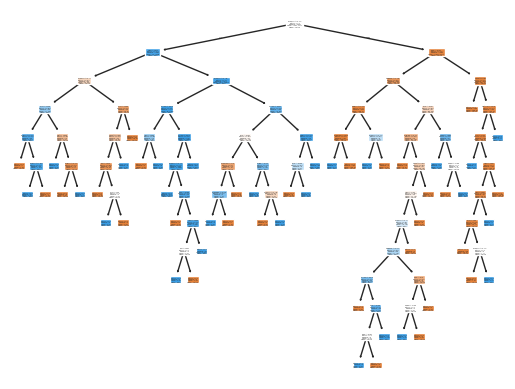

In [42]:
dt = tree.DecisionTreeClassifier(
    criterion='entropy',
    random_state=0
)
dt.fit(X_train, y_train)

tree.plot_tree(
    decision_tree=dt,
    feature_names=X.columns,
    filled=True,
    impurity=True,
    class_names=dt.classes_
);

In [45]:
print('Tree depth:', dt.get_depth())
print('Tree leaves num:', dt.get_n_leaves())

Tree depth: 12
Tree leaves num: 54


In [46]:
y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

print("accuracy train:", round(metrics.accuracy_score(y_train, y_train_pred), 3))
print("accuracy test:", round(metrics.accuracy_score(y_test, y_test_pred), 3))

accuracy train: 1.0
accuracy test: 0.973


In [51]:
param_grid = {
    'criterion': ['gini', 'entropy'], #критерий информативности
    'max_depth': [4, 5, 6, 7, 8, 9, 10], #максимальная глубина дерева
    'min_samples_split': [3, 4, 5, 10] #минимальное количество объектов, необходимое для сплита
}
cv = model_selection.StratifiedKFold(n_splits=5)

grid_search = model_selection.GridSearchCV(
    estimator=tree.DecisionTreeClassifier(
        random_state=0,
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs = -1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=DecisionTreeClassifier(random_state=0), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8, 9, 10],
                         'min_samples_split': [3, 4, 5, 10]},
             scoring='accuracy')

In [52]:
print(grid_search.best_params_)

{'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 3}


In [53]:
y_train_pred = grid_search.predict(X_train)
y_test_pred = grid_search.predict(X_test)

print("accuracy train:", round(metrics.accuracy_score(y_train, y_train_pred), 3))
print("accuracy test:", round(metrics.accuracy_score(y_test, y_test_pred), 3))

accuracy train: 0.996
accuracy test: 0.97


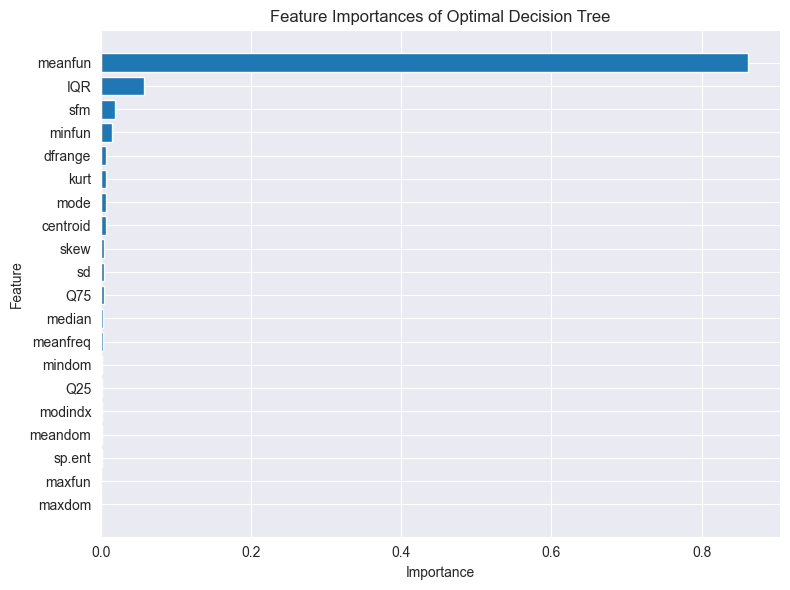

In [54]:
# 1. Извлекаем оптимальную модель из GridSearchCV
best_tree = grid_search.best_estimator_

# 2. Получаем вектор важностей и имена признаков
importances = best_tree.feature_importances_
if hasattr(X_train, 'columns'):
    feature_names = X_train.columns
else:
    feature_names = [f'Feature {i}' for i in range(len(importances))]

# 3. Сортируем по возрастанию важности
indices = np.argsort(importances)

# 4. Строим столбчатую диаграмму
plt.figure(figsize=(8, 6))
plt.barh(np.array(feature_names)[indices], importances[indices])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importances of Optimal Decision Tree')
plt.tight_layout()
plt.show()